In [20]:
%matplotlib inline
%load_ext autoreload
%load_ext ipython_gpt
%autoreload 2

import os
import sys
import copy 

from astropy.cosmology import FlatLambdaCDM
from astropy.table import Table, Column, vstack, join

import numpy as np 

import matplotlib.pyplot as plt
from matplotlib import rcParams

plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 25})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

In [2]:
def dist_mod(d_mpc):
    """Distance modulus."""
    return 5. * np.log10(d_mpc * 1e5)

## Reproduce Johnny's GCLF figure

In [10]:
gaia_tables = Gaia.load_tables(only_names=True)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]


In [15]:
[print(t.get_qualified_name()) for t in gaia_tables if 'gaiadr3' in t.get_qualified_name()];

gaiadr3.gaiadr3.gaia_source
gaiadr3.gaiadr3.gaia_source_lite
gaiadr3.gaiadr3.astrophysical_parameters
gaiadr3.gaiadr3.astrophysical_parameters_supp
gaiadr3.gaiadr3.oa_neuron_information
gaiadr3.gaiadr3.oa_neuron_xp_spectra
gaiadr3.gaiadr3.total_galactic_extinction_map
gaiadr3.gaiadr3.total_galactic_extinction_map_opt
gaiadr3.gaiadr3.commanded_scan_law
gaiadr3.gaiadr3.allwise_best_neighbour
gaiadr3.gaiadr3.allwise_neighbourhood
gaiadr3.gaiadr3.apassdr9_best_neighbour
gaiadr3.gaiadr3.apassdr9_join
gaiadr3.gaiadr3.apassdr9_neighbourhood
gaiadr3.gaiadr3.dr2_neighbourhood
gaiadr3.gaiadr3.gsc23_best_neighbour
gaiadr3.gaiadr3.gsc23_join
gaiadr3.gaiadr3.gsc23_neighbourhood
gaiadr3.gaiadr3.hipparcos2_best_neighbour
gaiadr3.gaiadr3.hipparcos2_neighbourhood
gaiadr3.gaiadr3.panstarrs1_best_neighbour
gaiadr3.gaiadr3.panstarrs1_join
gaiadr3.gaiadr3.panstarrs1_neighbourhood
gaiadr3.gaiadr3.ravedr5_best_neighbour
gaiadr3.gaiadr3.ravedr5_join
gaiadr3.gaiadr3.ravedr5_neighbourhood
gaiadr3.gaiadr3.ravedr

In [53]:
# Define the NGC3115 galaxy's coordinates (RA, Dec)
ngc3115_coords = SkyCoord(ra=151.3083 * u.degree, dec=-7.725 * u.degree)

# Define the search radius
search_radius = 0.3 * u.degree

# Perform the query using Gaia DR3 and cross-match with astrophysical_parameters
query = f"""SELECT g.*, ap.*
            FROM gaiadr3.gaia_source AS g
            INNER JOIN gaiadr3.astrophysical_parameters AS ap ON g.source_id = ap.source_id
            WHERE 1=CONTAINS(
                POINT('ICRS', g.ra, g.dec),
                CIRCLE('ICRS', {ngc3115_coords.ra.value}, {ngc3115_coords.dec.value}, {search_radius.value})
            )
            """

job = Gaia.launch_job_async(query)
n3115_cat = job.get_results()

# Print the results
print(n3115_cat)

INFO: Query finished. [astroquery.utils.tap.core]
    solution_id             DESIGNATION               source_id      ... neuron_oa_dist_percentile_rank flags_oa
                                                                     ...                                        
------------------- ---------------------------- ------------------- ... ------------------------------ --------
1636148068921376768 Gaia DR3 3772282699634387200 3772282699634387200 ...                             25     2043
1636148068921376768 Gaia DR3 3772282768353348992 3772282768353348992 ...                             75     0013
1636148068921376768 Gaia DR3 3772282768353684480 3772282768353684480 ...                             75     0012
1636148068921376768 Gaia DR3 3772282768354032000 3772282768354032000 ...                             50     0033
1636148068921376768 Gaia DR3 3772282802713321600 3772282802713321600 ...                             25     2245
1636148068921376768 Gaia DR3 37722828714325666

In [73]:
mask = ((n3115_cat['astrometric_excess_noise'] > 10.) & 
        (n3115_cat['phot_bp_rp_excess_factor'] > 1.7) & 
        (n3115_cat["classprob_dsc_combmod_galaxy_2"] < 0.1)
       )

mask.sum()

52

(17.0, 23.0)

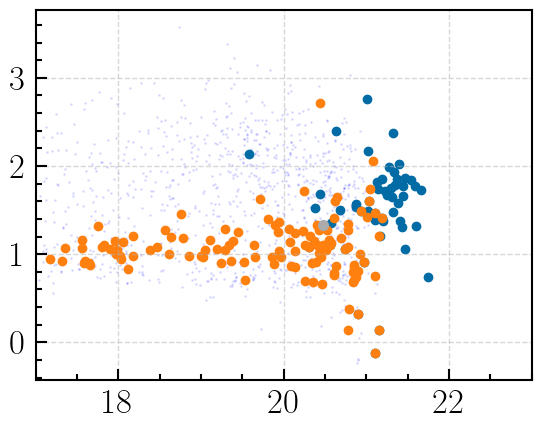

In [82]:
plt.scatter(
    n3115_cat['phot_g_mean_mag'], 
    n3115_cat['phot_bp_mean_mag'] - n3115_cat['phot_rp_mean_mag'], 
    s=1, alpha=0.1, color='b'
)

plt.scatter(
    n3115_cat['phot_g_mean_mag'][mask], 
    n3115_cat['phot_bp_mean_mag'][mask] - n3115_cat['phot_rp_mean_mag'][mask]
)

plt.scatter(
    n3115_gc['phot_g_mean_mag'], 
    n3115_gc['phot_bp_mean_mag'] - n3115_gc['phot_rp_mean_mag'], 
)

plt.scatter(
    n3115_ucd['phot_g_mean_mag'], 
    n3115_ucd['phot_bp_mean_mag'] - n3115_ucd['phot_rp_mean_mag'],
    s=50
)

plt.xlim(17.0, 23.0)

In [76]:
#[print(obj['ra'], obj['dec']) for obj in n3115_cat[mask]];
#[print(obj['ra'], obj['dec']) for obj in n3115_ucd];
[print(obj['ra'], obj['dec']) for obj in n3115_gc];

151.31567938808197 -7.714338151959408
151.33823502906552 -7.693637991504288
151.29078110557663 -7.720578315034411
151.3045620147161 -7.732747773185529
151.34852731325236 -7.698300561471301
151.33398612166027 -7.695516431715967
151.3259886118166 -7.73551506765057
151.30493780731206 -7.704779742876092
151.3177589084371 -7.709779557964244
151.28995772781616 -7.700170635793967
151.2951509775794 -7.7287835152900435
151.2975509316459 -7.749833451723254
151.3199127909571 -7.7796549871403915
151.29707556868385 -7.705923548249999
151.32932281171998 -7.739336256562577
151.3213936940557 -7.713262479168136
151.304748930571 -7.739653366931878
151.31000181208188 -7.726070678132912
151.32144798065661 -7.722001914533872
151.25208837266084 -7.713443059801481
151.27531521764737 -7.741161264879343
151.34530612176502 -7.684986579791714
151.31857886706112 -7.716406341748538
151.31142017600635 -7.6494015120264205
151.33044046396796 -7.738803491075964
151.31984501217897 -7.718770115255817
151.3309190189094 -

In [70]:
n3115_ucd = Table.read('/Users/shuang/Downloads/n3115_ucd.fits')
n3115_gc = Table.read('/Users/shuang/Downloads/n3115_gc.fits')

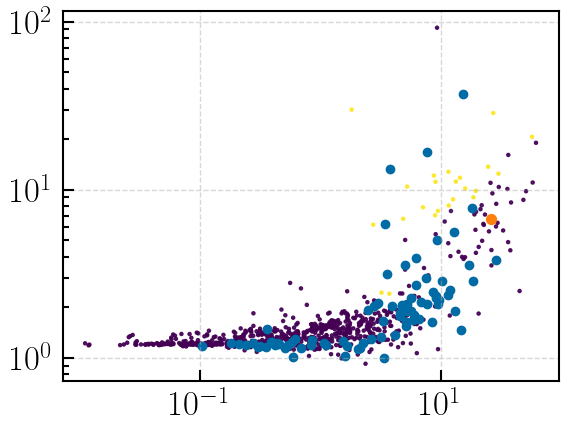

In [71]:
plt.scatter(n3115_cat['astrometric_excess_noise'], n3115_cat['phot_bp_rp_excess_factor'], 
            s=5, alpha=0.9, c=n3115_cat["classprob_dsc_combmod_galaxy_2"])
plt.loglog()

plt.scatter(n3115_gc['astrometric_excess_noise'], n3115_gc['phot_bp_rp_excess_factor']) 
plt.scatter(n3115_ucd['astrometric_excess_noise'], n3115_ucd['phot_bp_rp_excess_factor'], s=50) 


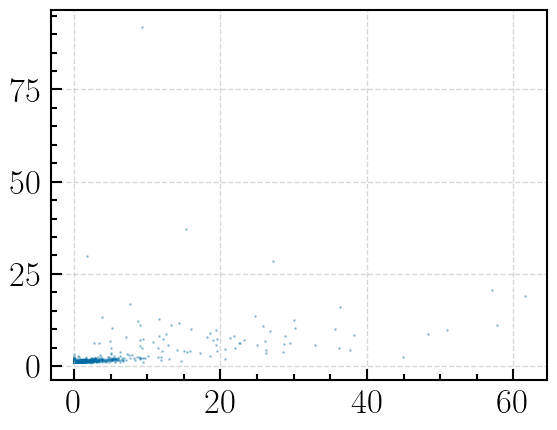

In [72]:
plt.scatter(n3115_cat['astrometric_excess_noise'], n3115_cat['phot_bp_rp_excess_factor'], s=1, alpha=0.3)

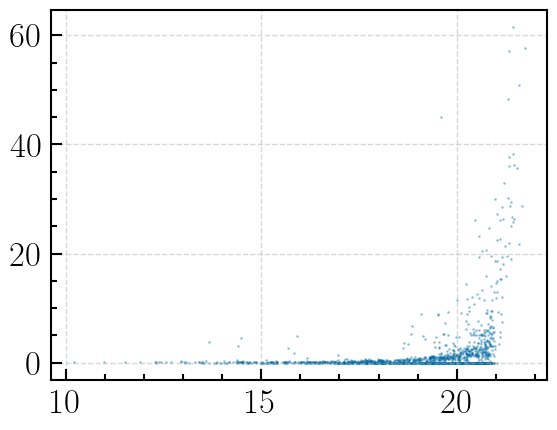

In [58]:
plt.scatter(n3115_cat['phot_g_mean_mag'], n3115_cat['astrometric_excess_noise'], s=1, alpha=0.3)

In [21]:
n3115_cat.colnames

['solution_id',
 'DESIGNATION',
 'source_id',
 'random_index',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'ra_dec_corr',
 'ra_parallax_corr',
 'ra_pmra_corr',
 'ra_pmdec_corr',
 'dec_parallax_corr',
 'dec_pmra_corr',
 'dec_pmdec_corr',
 'parallax_pmra_corr',
 'parallax_pmdec_corr',
 'pmra_pmdec_corr',
 'astrometric_n_obs_al',
 'astrometric_n_obs_ac',
 'astrometric_n_good_obs_al',
 'astrometric_n_bad_obs_al',
 'astrometric_gof_al',
 'astrometric_chi2_al',
 'astrometric_excess_noise',
 'astrometric_excess_noise_sig',
 'astrometric_params_solved',
 'astrometric_primary_flag',
 'nu_eff_used_in_astrometry',
 'pseudocolour',
 'pseudocolour_error',
 'ra_pseudocolour_corr',
 'dec_pseudocolour_corr',
 'parallax_pseudocolour_corr',
 'pmra_pseudocolour_corr',
 'pmdec_pseudocolour_corr',
 'astrometric_matched_transits',
 'visibility_periods_used',
 'astrometric_sigma5d_max